# UROP Research Log — May 27, 2026

## Objective
1. Regression analysis (R_PBP vs R_BXM) — compute Adj. R², t-ratio
2. Extreme value analysis — identify dates with largest TE spikes
   and verify against market events (Reasonableness Check)

## Reasonings
Yesterday's baseline gave us 4.80% annualized TE, but that's just a number.
Before moving to Stage 2 (Cboe tick data), I wanted to understand *what's 
driving* that number — is the noise random (synchronicity) or structured 
(expense ratio, smearing)? Regression tells us how tightly PBP tracks BXM 
statistically, and extreme value dates give us concrete, story-worthy examples 
of the synchronicity problem in action. Both pieces will go directly into the 
paper's methodology and results sections.

## Data Sources
- Reusing merged 2022 dataframe structure from may26_Baseline.ipynb
- Raw CSVs: ../data/raw/HistoricalData_PBP.csv, BXM_History.csv

## Approach
1. Reload and rebuild df from scratch (self-contained notebook)
2. OLS regression: R_PBP ~ R_BXM
3. Extract top 5 positive / top 5 negative TE dates
4. Cross-reference with 2022 market events

## Notes
- Tomorrow: Replace PBP data with Bloomberg 1-min intraday (Wilson Library)
- Cboe tick data arriving soon → Stage 2 begins

In [1]:
# -- Reload Data --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load raw CSVs
pbp = pd.read_csv("../data/raw/HistoricalData_PBP.csv")
bxm = pd.read_csv("../data/raw/BXM_History.csv")

# Parse dates
pbp["Date"] = pd.to_datetime(pbp["Date"])
bxm["DATE"] = pd.to_datetime(bxm["DATE"])

# Filter 2022
pbp_2022 = pbp[pbp["Date"].dt.year == 2022].copy().sort_values("Date").reset_index(drop=True)
bxm_2022 = bxm[bxm["DATE"].dt.year == 2022].copy().sort_values("DATE").reset_index(drop=True)

# Rename & merge
pbp_2022 = pbp_2022.rename(columns={"Date": "date", "Close/Last": "pbp_close"})
bxm_2022 = bxm_2022.rename(columns={"DATE": "date", "BXM": "bxm_close"})
df = pd.merge(pbp_2022[["date", "pbp_close"]], bxm_2022[["date", "bxm_close"]], on="date", how="inner")

# Log returns
df["r_pbp"] = np.log(df["pbp_close"] / df["pbp_close"].shift(1))
df["r_bxm"] = np.log(df["bxm_close"] / df["bxm_close"].shift(1))
df["te_daily"] = df["r_pbp"] - df["r_bxm"]
df = df.dropna().reset_index(drop=True)

print("Ready:", len(df), "rows")
print(df.head(3))

Ready: 250 rows
        date  pbp_close  bxm_close     r_pbp     r_bxm  te_daily
0 2022-01-04      23.14    1778.63 -0.003451  0.000022 -0.003474
1 2022-01-05      23.08    1767.15 -0.002596 -0.006475  0.003879
2 2022-01-06      23.08    1768.30  0.000000  0.000651 -0.000651


=== OLS Regression: R_PBP ~ R_BXM (2022) ===
Slope (Beta)       : 0.982563
Intercept (Alpha)  : -0.000088  (-0.0088%)
R²                 : 0.917078
Adj. R²            : 0.916744
t-ratio (slope)    : 52.3714
p-value            : 0.000000


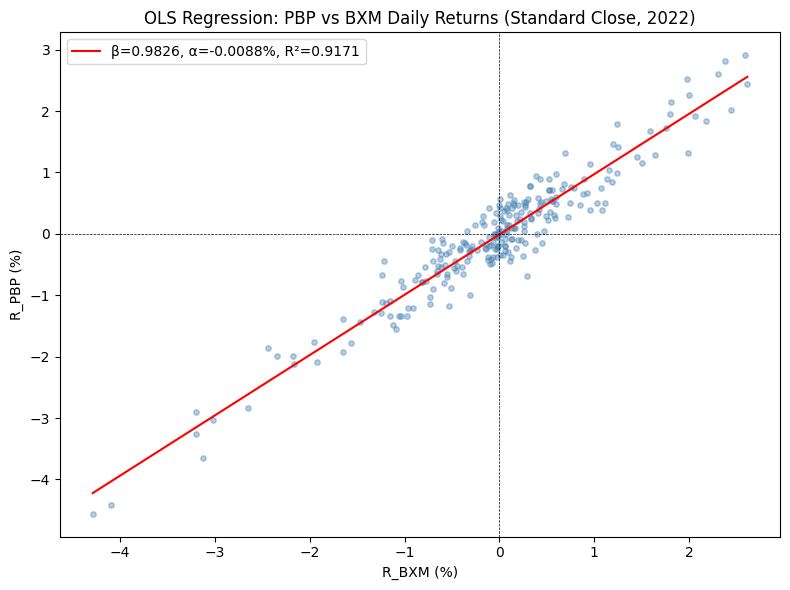

Plot saved.


In [ ]:
# -- OLS Regression (R_PBP ~ R_BXM) --

slope, intercept, r_value, p_value, std_err = stats.linregress(df["r_bxm"], df["r_pbp"])

r_squared = r_value ** 2
n = len(df)
k = 1  # number of predictors
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)
t_ratio = slope / std_err

print("=== OLS Regression: R_PBP ~ R_BXM (2022) ===")
print(f"Slope (Beta)       : {slope:.6f}")
print(f"Intercept (Alpha)  : {intercept:.6f}  ({intercept*100:.4f}%)")
print(f"R²                 : {r_squared:.6f}")
print(f"Adj. R²            : {adj_r_squared:.6f}")
print(f"t-ratio (slope)    : {t_ratio:.4f}")
print(f"p-value            : {p_value:.6f}")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["r_bxm"] * 100, df["r_pbp"] * 100, alpha=0.4, s=15, color="steelblue")
x_line = np.linspace(df["r_bxm"].min(), df["r_bxm"].max(), 100)
ax.plot(x_line * 100, (slope * x_line + intercept) * 100, color="red", linewidth=1.5,
        label=f"β={slope:.4f}, α={intercept*100:.4f}%, R²={r_squared:.4f}")
ax.set_xlabel("R_BXM (%)")
ax.set_ylabel("R_PBP (%)")
ax.set_title("OLS Regression: PBP vs BXM Daily Returns (Standard Close, 2022)")
ax.legend()
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.savefig("../data/processed/regression_PBP_BXM_2022.png", dpi=150)
plt.show()
print("Plot saved.")

In [3]:
# -- Extreme Value Analysis --

# Top 5 positive and negative TE dates
top5_pos = df.nlargest(5, "te_daily")[["date", "pbp_close", "bxm_close", "r_pbp", "r_bxm", "te_daily"]]
top5_neg = df.nsmallest(5, "te_daily")[["date", "pbp_close", "bxm_close", "r_pbp", "r_bxm", "te_daily"]]

print("=== Top 5 Positive TE Dates (PBP > BXM) ===")
print(top5_pos.to_string(index=False))
print("\n=== Top 5 Negative TE Dates (PBP < BXM) ===")
print(top5_neg.to_string(index=False))

=== Top 5 Positive TE Dates (PBP > BXM) ===
      date  pbp_close  bxm_close     r_pbp     r_bxm  te_daily
2022-12-15      20.40    1582.78 -0.004402 -0.012195  0.007793
2022-12-13      20.63    1597.53  0.013174  0.006954  0.006221
2022-12-06      20.29    1575.74 -0.000985 -0.007120  0.006135
2022-08-26      20.87    1610.47 -0.018515 -0.024395  0.005880
2022-02-03      22.44    1723.81 -0.006662 -0.012344  0.005681

=== Top 5 Negative TE Dates (PBP < BXM) ===
      date  pbp_close  bxm_close     r_pbp     r_bxm  te_daily
2022-12-14      20.49    1602.20 -0.006809  0.002919 -0.009728
2022-06-21      20.35    1580.55  0.003939  0.010827 -0.006888
2022-12-19      19.94    1558.36 -0.009980 -0.003114 -0.006866
2022-03-15      22.18    1711.08  0.013161  0.019886 -0.006725
2022-02-02      22.59    1745.22 -0.002653  0.003789 -0.006441


## Results Summary (May 27, 2026)

### Regression Analysis
| Metric | Value |
|--------|-------|
| Beta (Slope) | 0.9826 |
| Alpha (Intercept) | -0.0088% |
| R² | 0.9171 |
| Adj. R² | 0.9167 |
| t-ratio | 52.37 |
| p-value | ~0.000 |

**Interpretation**: R² = 0.9171 means BXM explains 91.71% of PBP's daily return variation.
The remaining 8.29% (Unexplained) is attributable to the Synchronicity Problem and Qualitative TE sources confirmed in the Prospectus.

### Extreme Value Analysis — Reasonableness Check
| Date | TE | Market Event |
|------|-----|--------------|
| 2022-12-14 | -0.97% | FOMC rate decision released at 2:00 PM ET |
| 2022-12-15 | +0.78% | Day-after rebound from FOMC shock |
| 2022-12-13 | +0.62% | FOMC meeting day 1 — pre-announcement volatility |
| 2022-08-26 | +0.59% | Jackson Hole — Powell hawkish speech, S&P -3.37% |
| 2022-06-21 | -0.69% | Fed rate hike cycle volatility |
| 2022-03-15 | -0.67% | Pre-FOMC rate hike anticipation |
| 2022-02-02/03 | -0.64% / +0.57% | Consecutive spikes — Fed tightening fears |

## Why This Matters
The majority of extreme TE dates coincide with Fed events (FOMC, Jackson Hole).
I don't think this is not a coincidence. When the Fed releases major announcements between
4:00 PM and 4:15 PM ET, the market moves sharply in that 15-minute window,
creating an artificially large gap between PBP (4:00 PM close) and BXM (~4:15 PM close).
This is the Synchronicity Problem in its most extreme form, and it provides
concrete, event-driven evidence for why timestamp synchronization is essential.